## Zadania

#### Zadanie 1 (1 pkt)

Narysować 6 pierwszych wielomianów Hermita (na jednym wykresie albo siatce 2x3 lub 3x2) $H_m(x)$, $m \in \{0,1,...,5\}$

Podobnie  narysować 6 pierwszych funkcji bazowych z uwzględnieniem czynnika wagowego $H_m(x)\exp(-\frac{x^2}{2})$, $m \in \{0,1,...,5\}$

#### Zadanie 2 (1 pkt)

Pokazać, że same wielomiany nie są ortogonane, ale już z funkcją wagową $exp(-x^2)$ są. Uzyć metody z wektorami wartości, założyć pewien przedział.

#### Zadanie 3  (1 pkt)

Dokonać aproksymacji zespołu QRS typu N oraz V za pomocą kilku kolejnych stopni. Przedstawić osobno wykresy dla N i V.

#### Zadanie 4  (1 pkt)

Przedstawić wykres błędu aproksymacji w zależności od stopnia wielomianu dla stopni od 0 do 10. Jakiego stopnia należy użyć gdybyśmy mieli robić coś dalej z rezultatem aproksymacji?

In [66]:
using CSV, DataFrames, Plots, LinearAlgebra, Polynomials, SpecialPolynomials, Statistics

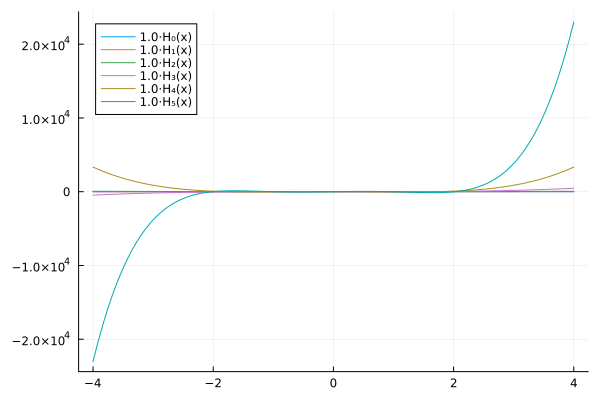

In [6]:
# Zadanie 1
# 6 pierwszych wielomianów Hermita H_m(x); m=0,1,...,5
# H_n+1(x) = 2x * H_n(x) - 2n * H_n-1(x)
# 2 sposoby: h0 = basis(Hermite, 0) oraz h0 = Hermite([1])
h0 = basis(Hermite, 0) # H_0 = 1
plot(h0, -4, 4)
h1 = basis(Hermite, 1) # H_1 = 2x
plot!(h1, -4, 4)
h2 = basis(Hermite, 2) 
plot!(h2, -4, 4)
h3 = basis(Hermite, 3) 
plot!(h3, -4, 4)
h4 = basis(Hermite, 4) 
plot!(h4, -4, 4)
h5 = basis(Hermite, 5)
plot!(h5, -4, 4)

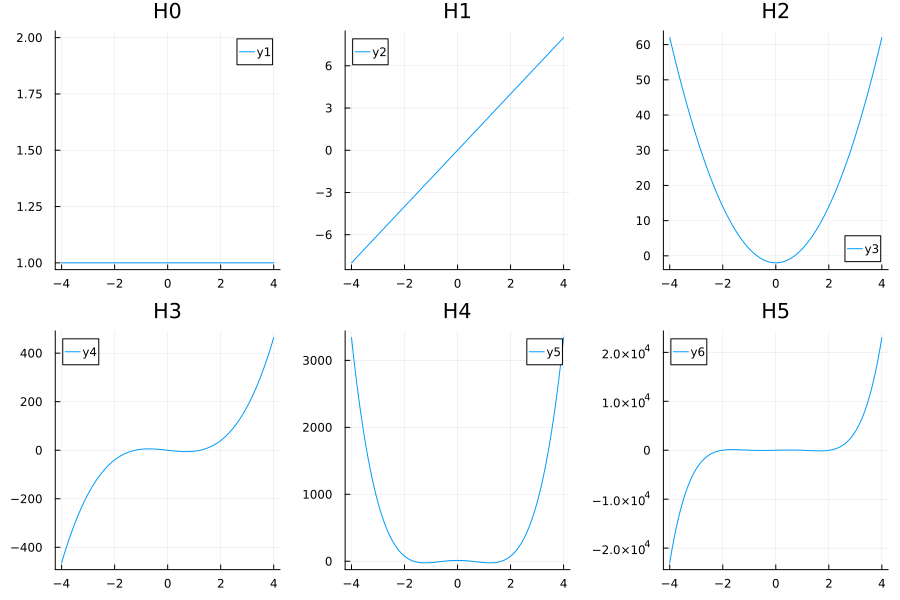

In [22]:
# 2 wersja - automatyczna - wykresy na siatce 2x3
plt = plot(layout = (2, 3), size=(900, 600))
x_vals = -4:0.01:4

for k in 0:5
    H_k = basis(Hermite, k)
    y_vals = H_k.(x_vals)
    plot!(x_vals, y_vals, subplot = k+1, title="H$k")
end

display(plt)

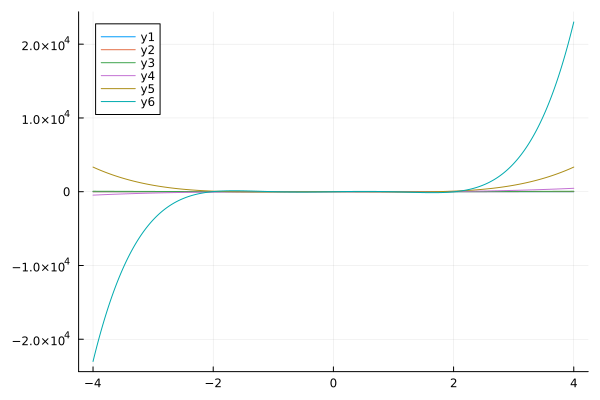

In [28]:
# 2 wersja - automatyczna - wszystkie na jednym wykresie
plt = plot()
x_vals = -4:0.01:4

for k in 0:5
    H_k = basis(Hermite, k)
    y_vals = H_k.(x_vals)
    plot!(plt, x_vals, y_vals)
end

display(plt)

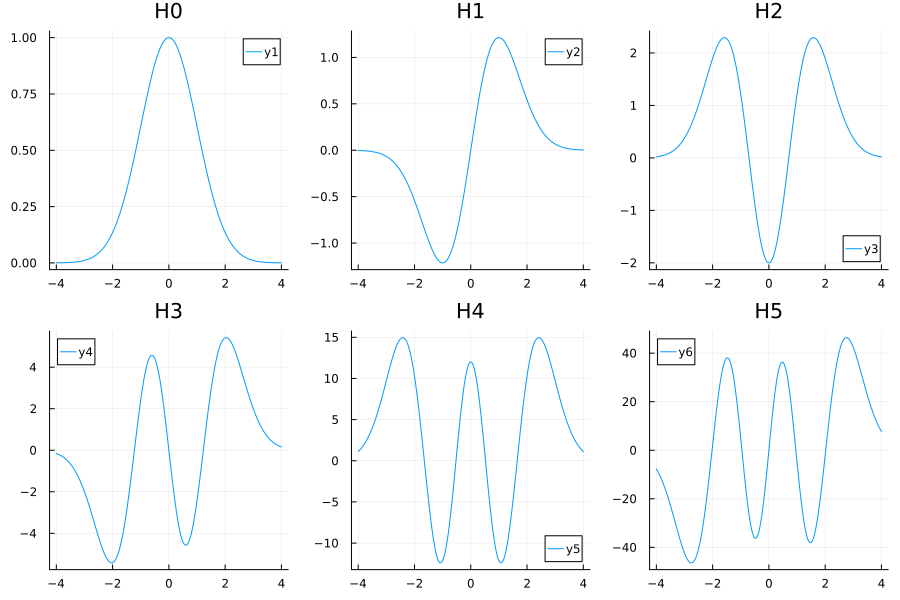

In [24]:
# 6 pierwszych funkcji bazowych z uwzględnieniem czynnika wagowego exp(-x^2/2)
plt = plot(layout = (2, 3), size=(900, 600))
x_vals = -4:0.01:4

for k in 0:5
    H_k = basis(Hermite, k)
    y_vals = [H_k(x) * exp(-x^2 / 2) for x in x_vals]
    plot!(x_vals, y_vals, subplot=k+1, title="H$k")
end

display(plt)

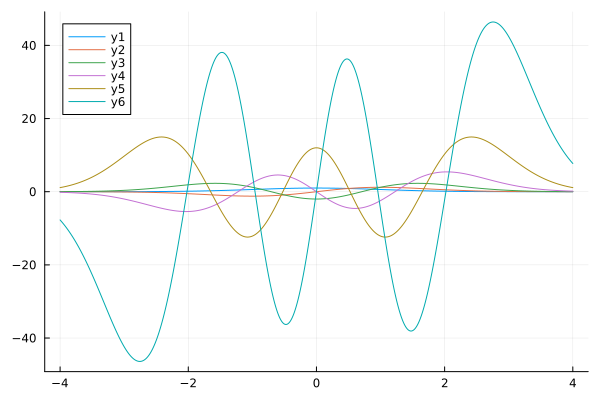

In [30]:
# 6 pierwszych funkcji bazowych z uwzględnieniem czynnika wagowego exp(-x^2/2) - wszystkie wykresy na jednym
plt = plot()
x_vals = -4:0.01:4

for k in 0:5
    H_k = basis(Hermite, k)
    y_vals = [H_k(x) * exp(-x^2 / 2) for x in x_vals]
    plot!(x_vals, y_vals)
end

display(plt)

In [50]:
# Zadanie 2
# Pokazać, że same wielomiany nie są ortogonalne, ale już z funkcją wagową exp(-x^2) są. 
# Uzyć metody z wektorami wartości, założyć pewien przedział.

# Wielomiany ortogonalne to rodzina wielomianów, w których iloczyn skalarny dwóch róznych wielomianów jest równa 0.
# <P_m,P_n>=\int_a^b P_n(x)P_m(x)W(x)dx = 0; \int_a^b - całka od a do b

# Definiujemy przedział
a = -5
b = 5
x_vals = a:0.1:b

# Funkcja do generowania wielomianów Hermite'a
function hermite_poly(n, x)
    return basis(Hermite, n).(x)
end

# Generujemy pierwsze sześć wielomianów Hermite'a
H0 = hermite_poly(0, x_vals)
H1 = hermite_poly(1, x_vals)
H2 = hermite_poly(2, x_vals)
H3 = hermite_poly(3, x_vals)
H4 = hermite_poly(4, x_vals)
H5 = hermite_poly(5, x_vals)

# Obliczamy iloczyny skalarne bez funkcji wagowej
dot_no_weight = Array{Float64, 2}(undef, 6, 6)

for (i, H_i) in enumerate([H0, H1, H2, H3, H4, H5])
    for (j, H_j) in enumerate([H0, H1, H2, H3, H4, H5])
        dot_no_weight[i, j] = dot(H_i, H_j)
    end
end

println("Iloczyny skalarne wielomianów Hermite'a bez funkcji wagowej:")
display(dot_no_weight)

# Teraz obliczamy iloczyny skalarne z funkcją wagową exp(-x^2)
weight_function = exp.(-x_vals.^2)

# Wielomiany z funkcją wagową
H0_weighted = H0 .* weight_function
H1_weighted = H1 .* weight_function
H2_weighted = H2 .* weight_function
H3_weighted = H3 .* weight_function
H4_weighted = H4 .* weight_function
H5_weighted = H5 .* weight_function

# Normalizacja dla lepszej interpretacji
H0_weighted_norm = normalize(H0_weighted)
H1_weighted_norm = normalize(H1_weighted)
H2_weighted_norm = normalize(H2_weighted)
H3_weighted_norm = normalize(H3_weighted)
H4_weighted_norm = normalize(H4_weighted)
H5_weighted_norm = normalize(H5_weighted)

# Obliczamy iloczyny skalarne z funkcją wagową
dot_with_weight = Array{Float64, 2}(undef, 6, 6)

for (i, H_i) in enumerate([H0_weighted_norm, H1_weighted_norm, H2_weighted_norm, H3_weighted_norm, H4_weighted_norm, H5_weighted_norm])
    for (j, H_j) in enumerate([H0_weighted_norm, H1_weighted_norm, H2_weighted_norm, H3_weighted_norm, H4_weighted_norm, H5_weighted_norm])
        dot_with_weight[i, j] = dot(H_i, H_j)
    end
end

println("\nIloczyny skalarne wielomianów Hermite'a z funkcją wagową exp(-x^2):")
display(dot_with_weight)

Iloczyny skalarne wielomianów Hermite'a bez funkcji wagowej:


6×6 Matrix{Float64}:
  101.0             3.55271e-15  3232.0          …  1.70137e5     4.36557e-11
    3.55271e-15  3434.0             1.13687e-13     2.91038e-11   1.13091e7
 3232.0             1.13687e-13     1.96801e5       1.2485e7     -2.79397e-9
   -4.54747e-13     1.89529e5       0.0             1.86265e-9    8.52416e8
    1.70137e5       2.91038e-11     1.2485e7        8.80768e8     1.19209e-7
    4.36557e-11     1.13091e7      -2.79397e-9   …  1.19209e-7    6.01582e10


Iloczyny skalarne wielomianów Hermite'a z funkcją wagową exp(-x^2):


6×6 Matrix{Float64}:
  1.0           3.63906e-19  -0.57735      …   0.29277      -1.65241e-17
  3.63906e-19   1.0           3.63056e-18      2.84782e-17   0.48795
 -0.57735       3.63056e-18   1.0             -0.845154     -5.2933e-18
 -2.03014e-17  -0.774597     -8.96235e-18      5.29685e-18  -0.881917
  0.29277       2.84782e-17  -0.845154         1.0          -5.83918e-18
 -1.65241e-17   0.48795      -5.2933e-18   …  -5.83918e-18   1.0

In [51]:
# Zadanie 3
# Dokonać aproksymacji zespołu QRS typu N oraz V za pomocą kilku kolejnych stopni. Przedstawić osobno wykresy dla N i V.

In [52]:
ekg_data = CSV.read("ecg_data.csv", DataFrame);

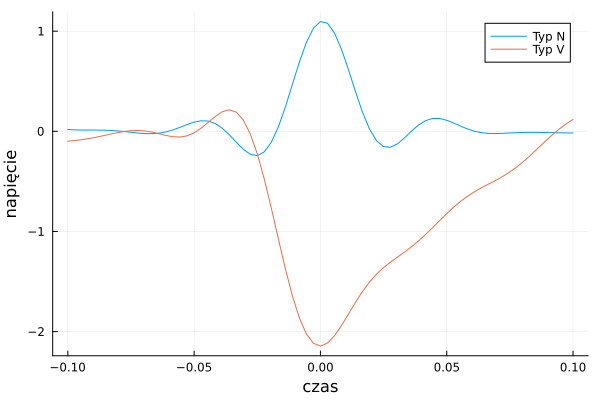

In [53]:
plot(ekg_data.time, ekg_data.signalN, label="Typ N", xlabel = "czas", ylabel="napięcie")
plot!(ekg_data.time, ekg_data.signalV, label="Typ V")

In [55]:
# Definicja węzłów
xx_ekg = ekg_data.time*40
yy_ekgV = ekg_data.signalV;
yy_ekgN = ekg_data.signalN;

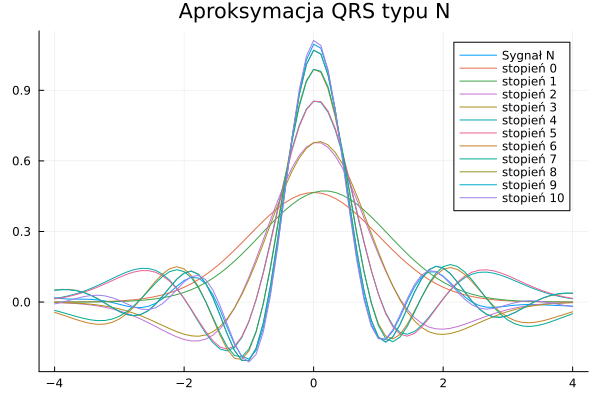

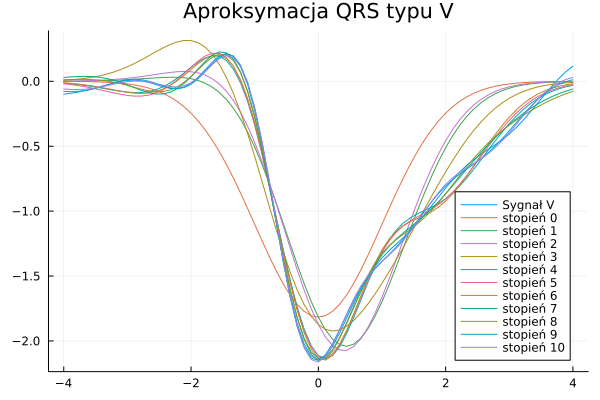

In [64]:
function base_fun(k, x, norm=true)
    H_k = basis(Hermite, k).(x)
    app = H_k .* exp.(-(x.^2)/2)
    # normalize to have norm 1
    if norm
        return normalize(app)
    end
    return app
end

max_k = 10
base_functions = [base_fun(k, xx_ekg, true) for k in 0:max_k]

coeffs_N = [dot(yy_ekgN, f) for f in base_functions]
coeffs_V = [dot(yy_ekgV, f) for f in base_functions]

function approximate_signal(coeffs, base_functions, max_degree)
    sum(coeffs[k+1] * base_functions[k+1] for k in 0:max_degree)
end

approx_N = [approximate_signal(coeffs_N, base_functions, k) for k in 0:max_k]
approx_V = [approximate_signal(coeffs_V, base_functions, k) for k in 0:max_k]

# Typ N
plt1 = plot(xx_ekg, yy_ekgN, label="Sygnał N", title="Aproksymacja QRS typu N")
for k in 0:max_k
    plot!(xx_ekg, approx_N[k+1], label="stopień $k")
end

display(plt1)

# Typ V
plt2 = plot(xx_ekg, yy_ekgV, label="Sygnał V", title="Aproksymacja QRS typu V")
for k in 0:max_k
    plot!(xx_ekg, approx_V[k+1], label="stopień $k")
end

display(plt2)

In [ ]:
# Zadanie 4
# Przedstawić wykres błędu aproksymacji w zależności od stopnia wielomianu dla stopni od 0 do 10. 
# Jakiego stopnia należy użyć gdybyśmy mieli robić coś dalej z rezultatem aproksymacji?

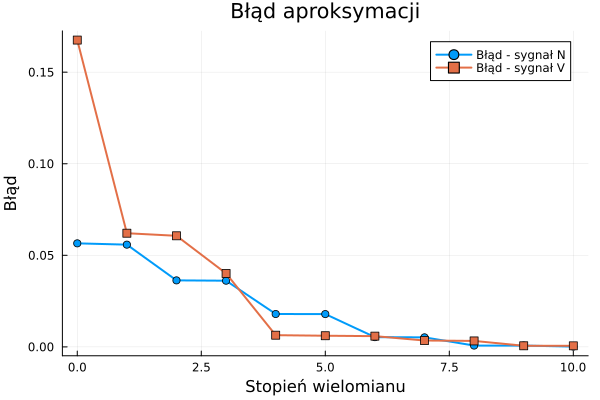

In [70]:
mse(y1, y2) = mean((y1 .- y2).^2)

errors_N = [mse(yy_ekgN, approx_N[k+1]) for k in 0:max_k]
errors_V = [mse(yy_ekgV, approx_V[k+1]) for k in 0:max_k]

plot(0:max_k, errors_N, label="Błąd - sygnał N", lw=2, marker=:circle)
plot!(0:max_k, errors_V, label="Błąd - sygnał V", lw=2, marker=:square,
    xlabel="Stopień wielomianu", ylabel="Błąd", title="Błąd aproksymacji")

# Najlepiej użyć stopnia 9 lub 10, przy których są juz praktycznie niezauważalne błędy.